In [13]:
import sys, os, io, pickle, warnings
from contextlib import redirect_stdout
warnings.filterwarnings('ignore')

SRC = os.path.join(os.getcwd(), 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, Parameter
from scipy.linalg import eigh as scipy_eigh
from tqdm.notebook import tqdm
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from graph_utils import get_active_stocks, correlation_matrix, prepare_node_features

# ---------- Patch 1: WaveConv.__init__ – use CPU instead of hard-coded CUDA ----------
import WaveConv as _wc_module
import layer as _layer_module

_Wave_prop = _layer_module.Wave_prop
_WaveConv  = _wc_module.WaveConv

def _wavconv_init_patched(self, dataset, in_channels, out_channels, args):
    nn.Module.__init__(self)
    self.args = args
    self.lin1 = Linear(in_channels, args.hidden_channels_wave)
    self.lin2 = Linear(args.hidden_channels_wave, out_channels)
    self.toy  = False
    eigen, eigen_vector = dataset.eigenvalues, dataset.vectors
    _dev = torch.device('cpu')
    self.eigen        = eigen.to(_dev)
    self.eigen_vector = eigen_vector.to(_dev)
    N = len(self.eigen)
    self.prop     = _Wave_prop(args.K, N)
    self.dprate   = args.dprate
    self.dropout  = args.dropout
    self.Pro_Matrix = None

_WaveConv.__init__ = _wavconv_init_patched

# ---------- Patch 2: Wave_prop.forward – remove two debug print statements ----------
def _quiet_wave_forward(self, x, eigen, eigen_vector, kernel='haar'):
    TEMP = self.temp
    if kernel == 'haar':
        Pro_Matrix = TEMP[0] * self.Haar(eigen, scale=0)
        for i in range(1, self.translation_max):
            Pro_Matrix += TEMP[i] * self.Haar(eigen, scale=i)
    elif kernel == 'db2':
        Pro_Matrix = TEMP[0] * self.Db2(eigen, translation=0)
        for i in range(1, self.translation_max):
            Pro_Matrix += TEMP[i] * self.Db2(eigen, translation=i)
    elif kernel == 'db4':
        Pro_Matrix = TEMP[0] * self.Db4(eigen, translation=0)
        for i in range(1, self.translation_max):
            Pro_Matrix += TEMP[i] * self.Db4(eigen, translation=i)
    else:
        raise ValueError('Wavelet kernel not supported.')
    Pro_Matrix = eigen_vector @ torch.diag(Pro_Matrix) @ eigen_vector.T
    x = Pro_Matrix @ x
    return x, Pro_Matrix

_Wave_prop.forward = _quiet_wave_forward
print('Patches applied.')

Patches applied.


In [14]:
import argparse
from model import GNNStructEncoder
from utils import get_normalization

def make_grasped_args():
    args = argparse.Namespace()
    # Encoder
    args.encoder              = 'WaveNet'
    args.wave_kernel          = 'haar'
    args.K                    = 8          # wavelet bases
    args.hidden_channels_wave = 64
    args.dprate               = 0.0
    args.dropout              = 0.2
    # Decoder
    args.feat_decoder = 'Deconv'
    args.gamma        = [0.1, 1.0, 10.0]  # MUST be a list — DeconvWiener does len(gamma)
    args.dec_kernel   = 'heat'
    args.dec_aggr     = 'sum'
    args.simple_dec   = True               # dec_layer = 1
    args.gnn_layer_num = 2
    args.skip         = False
    args.large        = False
    args.beta         = 0.5
    args.act          = 'prelu'
    args.norm         = ''
    args.drop_ratio   = 0.0
    # Loss weights
    args.lambda_loss1 = 0.0   # neighbor reconstruction
    args.lambda_loss2 = 1.0   # feature reconstruction
    args.lambda_loss3 = 0.0   # degree
    # Anomaly score weights (used at test time)
    args.h_loss_weight       = 0.0
    args.feature_loss_weight = 1.0
    args.degree_loss_weight  = 0.0
    # Other
    args.aggregator   = 'mean'
    args.sample_size  = 10
    args.hidden_dimension = 32
    args.dataset      = 'finance'   # avoids toy-graph branch in WaveConv
    args.norm_type    = 'sym'
    return args

DEVICE = torch.device('cpu')
print('Args builder ready. Device:', DEVICE)

Args builder ready. Device: cpu


In [15]:
# ── Load prices ──────────────────────────────────────────────────────────────
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0, 1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)

all_stocks = prices.columns.tolist()
stock2idx  = {s: i for i, s in enumerate(all_stocks)}
idx2stock  = {i: s for s, i in stock2idx.items()}
N_FULL     = len(all_stocks)
print(f'Universe: {N_FULL} stocks')

# ── Returns ───────────────────────────────────────────────────────────────────
returns = prices.pct_change().dropna(how='all')

train_returns = returns.loc['2012-01-01':'2016-12-31'].ffill().bfill()
val_returns   = returns.loc['2017-01-01':'2019-06-30']
test_returns  = returns.loc['2019-07-01':'2024-12-31'].ffill().bfill()

# ── Helper to load factor CSV files ──────────────────────────────────────────
def load_and_fix_index(path):
    df = pd.read_csv(path, index_col=0)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    return df

# ── Factor data ───────────────────────────────────────────────────────────────
Market_caps  = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')
PE_ratios    = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')
Implied_vol  = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')
Beta         = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
Turnover     = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')

train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
test_volatility  = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
volatility = pd.concat([train_volatility, test_volatility]).sort_index()

feature_dfs_list = [volatility, Market_caps, PE_ratios, Implied_vol, Beta, RSI_momentum, Turnover]

def precompute_zscores(df, window=63):
    mu  = df.rolling(window=window, min_periods=1).mean()
    std = df.rolling(window=window, min_periods=1).std().replace(0, np.nan)
    z   = (df - mu) / std
    return z.fillna(0.0)

Z_DATA = {
    'volatility':  precompute_zscores(volatility),
    'market_caps': precompute_zscores(Market_caps),
    'pe_ratios':   precompute_zscores(PE_ratios),
    'implied_vol': precompute_zscores(Implied_vol),
    'beta':        precompute_zscores(Beta),
    'rsi':         precompute_zscores(RSI_momentum),
    'turnover':    precompute_zscores(Turnover),
}
FEATURE_DIM = len(Z_DATA)
print(f'Feature dim: {FEATURE_DIM}')

Universe: 503 stocks
Feature dim: 7


In [16]:
class _MockDataset:
    """Thin wrapper so GNNStructEncoder / WaveConv get a .eigenvalues/.vectors object."""
    def __init__(self, eigenvalues, vectors):
        self.eigenvalues = eigenvalues
        self.vectors     = vectors


def compute_eigenbasis(A_full_np):
    """Compute sym-normalised Laplacian eigenbasis from a weighted adjacency matrix."""
    A = np.array(A_full_np, dtype=np.float64)
    A = (A + A.T) / 2
    A[A > 0] = 1.0   # binarise (consistent with decompose_graph.normalize_graph)
    deg = A.sum(axis=1)
    deg[deg == 0] = 1.0
    D_inv_sqrt = np.diag(deg ** -0.5)
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    L = np.eye(A.shape[0]) - A_norm
    evals, evecs = scipy_eigh(L)
    return (torch.tensor(evals, dtype=torch.float32),
            torch.tensor(evecs, dtype=torch.float32))


class DailyGraphBuilder:
    def __init__(self, returns, all_stocks, stock2idx, lookback_k=21, k_neighbors=10):
        self.returns    = returns
        self.all_stocks = all_stocks
        self.stock2idx  = stock2idx
        self.N          = len(all_stocks)
        self.K          = lookback_k
        self.kn         = k_neighbors

    def build(self, t, feature_dfs=None):
        active = get_active_stocks(
            self.returns, t,
            lookback_days=int(self.K * 1.5),
            feature_dfs=feature_dfs,
            min_obs=self.K
        )
        if len(active) < 2:
            return None

        corr, active_cols = correlation_matrix(self.returns, t, self.K, active=active)
        n_local = len(active_cols)

        # Build local top-k unsigned adjacency, then embed into N x N global space
        C = corr.copy()
        np.fill_diagonal(C, 0.0)
        A_full = np.zeros((self.N, self.N), dtype=np.float32)

        for i_loc in range(n_local):
            gi = self.stock2idx[active_cols[i_loc]]
            abs_c = np.abs(C[i_loc])
            k = min(self.kn, n_local - 1)
            top_k = np.argpartition(abs_c, -k)[-k:]
            for j_loc in top_k:
                gj = self.stock2idx[active_cols[j_loc]]
                A_full[gi, gj] = float(np.abs(corr[i_loc, j_loc]))

        # Symmetrize
        A_full = (A_full + A_full.T) / 2

        # Build edge list: correlation edges + self-loops for ALL N nodes
        rows, cols_arr = np.nonzero(A_full)
        src_list = rows.tolist() + list(range(self.N))
        dst_list = cols_arr.tolist() + list(range(self.N))

        edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)

        # neighbor_dict (source -> list of destinations)
        neighbor_dict = {i: [] for i in range(self.N)}
        for u, v in zip(src_list, dst_list):
            neighbor_dict[u].append(v)

        neighbor_num_list = torch.tensor(
            [len(neighbor_dict[i]) for i in range(self.N)], dtype=torch.long
        )

        global_idx = torch.tensor(
            [self.stock2idx[s] for s in active_cols], dtype=torch.long
        )

        return {
            'active_cols':        active_cols,
            'global_idx':         global_idx,
            'edge_index':         edge_index,
            'A_full':             A_full,
            'neighbor_dict':      neighbor_dict,
            'neighbor_num_list':  neighbor_num_list,
        }


def inject_eigenbasis(model, eigenvalues, eigenvectors, device):
    """Overwrite WaveConv eigen attributes before each day's forward pass."""
    for conv in (model.graphconv1, model.graphconv2):
        conv.eigen        = eigenvalues.to(device)
        conv.eigen_vector = eigenvectors.to(device)


def build_norm_edges(edge_index, N, device):
    """Return (sym edge_index/weight, rw edge_index/weight) on device."""
    ei_sym, ew_sym = get_normalization(
        edge_index.cpu(), N, improved=1.0, dtype=torch.float32, norm='sym', laplacian=False
    )
    ei_rw, ew_rw = get_normalization(
        edge_index.cpu(), N, improved=1.0, dtype=torch.float32, norm='rw', laplacian=False
    )
    return (ei_sym.to(device), ew_sym.to(device),
            ei_rw.to(device),  ew_rw.to(device))


def prepare_full_X(active_cols, global_idx, N, Z_DATA, t, device):
    """Build N x F feature tensor; inactive nodes get zeros."""
    x_active = prepare_node_features(active_cols, Z_DATA, t)   # n_active x F
    F_dim = x_active.shape[1]
    X = torch.zeros(N, F_dim, dtype=torch.float32)
    X[global_idx] = x_active
    return X.to(device)


def _safe_norm(v):
    mn, mx = v.min(), v.max()
    return (v - mn) / (mx - mn + 1e-12)


class EarlyStopping:
    def __init__(self, patience=5, save_path='outputs/grasped_model.pt', init_best_loss=float('inf')):
        self.patience  = patience
        self.save_path = save_path
        self.best_loss = init_best_loss
        self.counter   = 0
        self.stop      = False

    def __call__(self, val_loss, model, optimizer=None):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            ckpt = {'model': model.state_dict()}
            if optimizer is not None:
                ckpt['optimizer'] = optimizer.state_dict()
            torch.save(ckpt, self.save_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def load_checkpoint(save_path, model, optimizer=None):
    ckpt = torch.load(save_path)
    if isinstance(ckpt, dict) and 'model' in ckpt:
        model.load_state_dict(ckpt['model'])
        if optimizer is not None and 'optimizer' in ckpt:
            optimizer.load_state_dict(ckpt['optimizer'])
    else:
        model.load_state_dict(ckpt)


print('Helpers defined.')

Helpers defined.


In [17]:
from sklearn.metrics import roc_auc_score


def evaluate_once(test_results, prices, forward_window, crash_threshold):
    y_true, y_scores = [], []
    sorted_dates = sorted(test_results.keys())
    valid_dates = [
        d for d in sorted_dates
        if d <= prices.index[-1] - pd.Timedelta(days=forward_window)
    ]
    for t in valid_dates:
        stocks, signals = test_results[t]
        signals  = np.array(signals).flatten()
        available = [s for s in stocks if s in prices.columns]
        if not available:
            continue
        mask     = [i for i, s in enumerate(stocks) if s in available]
        signals  = signals[mask]
        p_t      = prices.loc[t, available]
        fut_idx  = prices.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if fut_idx >= len(prices):
            continue
        p_future    = prices.loc[prices.index[fut_idx], available]
        fwd_returns = (p_future - p_t) / p_t
        crash = (fwd_returns < crash_threshold).astype(int)
        y_true.extend(crash.values)
        y_scores.extend(signals)
    if not y_true:
        return None
    y_true, y_scores = np.array(y_true), np.array(y_scores)
    auc       = roc_auc_score(y_true, y_scores)
    baseline  = y_true.mean()
    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()
    lift      = precision / baseline if baseline > 0 else np.nan
    return auc, lift, baseline, precision


def test_grasped(model, dates, graph_cache, eigen_cache, Z_DATA, N, device):
    """Run GRASPED in eval mode; return {date: (active_stocks, signals)} dict."""
    model.eval()
    results = {}
    with torch.no_grad():
        for t in tqdm(dates, desc='Inference', leave=False):
            r = graph_cache.get(t)
            if r is None:
                continue
            evals, evecs = eigen_cache[t]
            inject_eigenbasis(model, evals, evecs, device)
            ei_sym, ew_sym, ei_rw, ew_rw = build_norm_edges(r['edge_index'], N, device)
            X_t    = prepare_full_X(r['active_cols'], r['global_idx'], N, Z_DATA, t, device)
            gt_deg = r['neighbor_num_list'].float().to(device)
            try:
                with redirect_stdout(io.StringIO()):
                    _, _, _, _, loss_per_node, _, _, _ = model(
                        ei_sym, ew_sym, ei_rw, ew_rw, X_t, gt_deg, r['neighbor_dict']
                    )
            except (ValueError, RuntimeError):
                continue
            signals_full  = loss_per_node.squeeze(-1).cpu().numpy()   # (N,)
            global_idx_np = r['global_idx'].numpy()
            results[t]    = (r['active_cols'], signals_full[global_idx_np])
    return results


print('evaluate_once, test_grasped defined.')


evaluate_once, test_grasped defined.


In [18]:
# train_grasped — identical to GRASPED_04May, kept here for reference.
# The BO uses train_grasped_bo (next cell) which is the same + epoch state saving.
def train_grasped(
    model, optimizer, train_dates, val_dates,
    graph_cache, eigen_cache, Z_DATA,
    N, device,
    n_epochs=50, patience=7,
    save_path='outputs/grasped_model.pt',
    start_epoch=0, init_train_hist=None, init_val_hist=None,
):
    init_best = min(init_val_hist) if init_val_hist else float('inf')
    early_stop = EarlyStopping(patience=patience, save_path=save_path, init_best_loss=init_best)
    train_hist = list(init_train_hist) if init_train_hist else []
    val_hist   = list(init_val_hist)   if init_val_hist   else []

    for epoch in range(start_epoch, n_epochs):
        model.train()
        epoch_loss = 0.0
        n_train    = 0

        for t in tqdm(train_dates, desc=f'Epoch {epoch+1}/{n_epochs} train', leave=False):
            r = graph_cache.get(t)
            if r is None:
                continue
            evals, evecs = eigen_cache[t]
            inject_eigenbasis(model, evals, evecs, device)
            ei_sym, ew_sym, ei_rw, ew_rw = build_norm_edges(r['edge_index'], N, device)
            X_t = prepare_full_X(r['active_cols'], r['global_idx'], N, Z_DATA, t, device)
            gt_deg = r['neighbor_num_list'].float().to(device)
            optimizer.zero_grad()
            try:
                with redirect_stdout(io.StringIO()):
                    loss, *_ = model(ei_sym, ew_sym, ei_rw, ew_rw, X_t, gt_deg, r['neighbor_dict'])
            except (ValueError, RuntimeError):
                continue
            if torch.isnan(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_train    += 1

        avg_train = epoch_loss / max(n_train, 1)
        train_hist.append(avg_train)

        model.eval()
        val_loss = 0.0
        n_val    = 0

        with torch.no_grad():
            for t in tqdm(val_dates, desc=f'Epoch {epoch+1}/{n_epochs} val', leave=False):
                r = graph_cache.get(t)
                if r is None:
                    continue
                evals, evecs = eigen_cache[t]
                inject_eigenbasis(model, evals, evecs, device)
                ei_sym, ew_sym, ei_rw, ew_rw = build_norm_edges(r['edge_index'], N, device)
                X_t = prepare_full_X(r['active_cols'], r['global_idx'], N, Z_DATA, t, device)
                gt_deg = r['neighbor_num_list'].float().to(device)
                try:
                    with redirect_stdout(io.StringIO()):
                        loss_v, *_ = model(ei_sym, ew_sym, ei_rw, ew_rw, X_t, gt_deg, r['neighbor_dict'])
                except (ValueError, RuntimeError):
                    continue
                if not torch.isnan(loss_v):
                    val_loss += loss_v.item()
                    n_val    += 1

        avg_val = val_loss / max(n_val, 1)
        val_hist.append(avg_val)
        print(f'Epoch {epoch+1:03d} | train={avg_train:.4f} | val={avg_val:.4f}')
        early_stop(avg_val, model, optimizer)
        if early_stop.stop:
            print('Early stopping.')
            break

    load_checkpoint(save_path, model, optimizer)
    return model, train_hist, val_hist

In [19]:
# train_grasped_bo — identical logic to train_grasped.
# Only addition: saves epoch-level state to bo_state_path after each epoch
# so that a crashed trial can be resumed from the last completed epoch.
def train_grasped_bo(
    model, optimizer, train_dates, val_dates,
    graph_cache, eigen_cache, Z_DATA,
    N, device,
    n_epochs=50, patience=7,
    save_path='outputs/grasped_model.pt',
    start_epoch=0, init_train_hist=None, init_val_hist=None,
    bo_state_path=None, bo_trial_params=None,
):
    init_best = min(init_val_hist) if init_val_hist else float('inf')
    early_stop = EarlyStopping(patience=patience, save_path=save_path, init_best_loss=init_best)
    train_hist = list(init_train_hist) if init_train_hist else []
    val_hist   = list(init_val_hist)   if init_val_hist   else []

    for epoch in range(start_epoch, n_epochs):
        model.train()
        epoch_loss = 0.0
        n_train    = 0

        for t in tqdm(train_dates, desc=f'Epoch {epoch+1}/{n_epochs} train', leave=False):
            r = graph_cache.get(t)
            if r is None:
                continue
            evals, evecs = eigen_cache[t]
            inject_eigenbasis(model, evals, evecs, device)
            ei_sym, ew_sym, ei_rw, ew_rw = build_norm_edges(r['edge_index'], N, device)
            X_t = prepare_full_X(r['active_cols'], r['global_idx'], N, Z_DATA, t, device)
            gt_deg = r['neighbor_num_list'].float().to(device)
            optimizer.zero_grad()
            try:
                with redirect_stdout(io.StringIO()):
                    loss, *_ = model(ei_sym, ew_sym, ei_rw, ew_rw, X_t, gt_deg, r['neighbor_dict'])
            except (ValueError, RuntimeError):
                continue
            if torch.isnan(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_train    += 1

        avg_train = epoch_loss / max(n_train, 1)
        train_hist.append(avg_train)

        model.eval()
        val_loss = 0.0
        n_val    = 0

        with torch.no_grad():
            for t in tqdm(val_dates, desc=f'Epoch {epoch+1}/{n_epochs} val', leave=False):
                r = graph_cache.get(t)
                if r is None:
                    continue
                evals, evecs = eigen_cache[t]
                inject_eigenbasis(model, evals, evecs, device)
                ei_sym, ew_sym, ei_rw, ew_rw = build_norm_edges(r['edge_index'], N, device)
                X_t = prepare_full_X(r['active_cols'], r['global_idx'], N, Z_DATA, t, device)
                gt_deg = r['neighbor_num_list'].float().to(device)
                try:
                    with redirect_stdout(io.StringIO()):
                        loss_v, *_ = model(ei_sym, ew_sym, ei_rw, ew_rw, X_t, gt_deg, r['neighbor_dict'])
                except (ValueError, RuntimeError):
                    continue
                if not torch.isnan(loss_v):
                    val_loss += loss_v.item()
                    n_val    += 1

        avg_val = val_loss / max(n_val, 1)
        val_hist.append(avg_val)
        print(f'Epoch {epoch+1:03d} | train={avg_train:.4f} | val={avg_val:.4f}')

        # ── Save epoch-level state for crash recovery (BO-only addition) ──────
        if bo_state_path is not None:
            _state = {
                'epoch':      epoch + 1,
                'train_hist': list(train_hist),
                'val_hist':   list(val_hist),
                'params':     bo_trial_params,
                'save_path':  save_path,
            }
            with open(bo_state_path, 'wb') as _f:
                pickle.dump(_state, _f)

        early_stop(avg_val, model, optimizer)
        if early_stop.stop:
            print('Early stopping.')
            break

    load_checkpoint(save_path, model, optimizer)
    return model, train_hist, val_hist


print('train_grasped and train_grasped_bo defined.')

train_grasped and train_grasped_bo defined.


In [20]:
from tqdm import tqdm
# LOOKBACK_K is tuned as suggest_int(10, 44) matching GAE_BayesianOptimisation.
# We pre-compute caches for 5 evenly-spaced values spanning that range.
# Inside the objective, the trial's LOOKBACK_K is snapped to the nearest
# pre-computed candidate so we avoid recomputing 35 separate caches.
LOOKBACK_K_CANDIDATES = [10, 18, 26, 35, 44]

os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/bo_caches', exist_ok=True)

CACHES = {}  # lookback_k -> dict with graph_cache, eigen_cache, train_dates, val_dates, test_dates

for lk in LOOKBACK_K_CANDIDATES:
    cache_path = f'outputs/bo_caches/cache_lk{lk}.pkl'

    if os.path.exists(cache_path):
        print(f'Loading LOOKBACK_K={lk} cache from disk...')
        with open(cache_path, 'rb') as f:
            CACHES[lk] = pickle.load(f)
        print(f'  Loaded: {len(CACHES[lk]["graph_cache"])} dates')
        continue

    print(f'Building cache for LOOKBACK_K={lk}...')
    builder = DailyGraphBuilder(returns, all_stocks, stock2idx, lookback_k=lk)

    min_train_lk   = train_returns.index[0] + pd.Timedelta(days=lk * 2)
    train_dates_lk = train_returns.loc[min_train_lk:].index
    val_dates_lk   = val_returns.index
    min_test_lk    = test_returns.index[0] + pd.Timedelta(days=lk * 2)
    test_dates_lk  = test_returns.loc[min_test_lk:].index

    all_dates_lk = sorted(set(
        list(train_dates_lk) + list(val_dates_lk) + list(test_dates_lk)
    ))

    graph_cache_lk = {}
    eigen_cache_lk = {}

    for t in tqdm(all_dates_lk, desc=f'LOOKBACK_K={lk}'):
        r = builder.build(t, feature_dfs=feature_dfs_list)
        if r is None:
            continue
        evals, evecs = compute_eigenbasis(r['A_full'])
        del r['A_full']  # not needed after eigenbasis; drop to save memory
        graph_cache_lk[t] = r
        eigen_cache_lk[t] = (evals, evecs)

    CACHES[lk] = {
        'graph_cache': graph_cache_lk,
        'eigen_cache': eigen_cache_lk,
        'train_dates': train_dates_lk,
        'val_dates':   val_dates_lk,
        'test_dates':  test_dates_lk,
    }

    print(f'  Built: {len(graph_cache_lk)} dates. Saving to disk...')
    with open(cache_path, 'wb') as f:
        pickle.dump(CACHES[lk], f)
    print(f'  Saved to {cache_path}')

print('All caches ready.')

Loading LOOKBACK_K=10 cache from disk...
  Loaded: 3243 dates
Loading LOOKBACK_K=18 cache from disk...
  Loaded: 3220 dates
Loading LOOKBACK_K=26 cache from disk...
  Loaded: 3197 dates
Loading LOOKBACK_K=35 cache from disk...
  Loaded: 3174 dates
Loading LOOKBACK_K=44 cache from disk...
  Loaded: 3146 dates
All caches ready.


In [21]:
import random

RESUME_STATE_PATH = 'outputs/bo_resume_state.pkl'

BO_EPOCHS_PER_TRIAL = 20
BO_PATIENCE         = 5


def objective(trial):
    # ── Sample hyperparameters ────────────────────────────────────────────────
    K_val                = trial.suggest_int('K', 4, 16)
    hidden_channels_wave = trial.suggest_categorical('hidden_channels_wave', [32, 64, 128])
    beta                 = trial.suggest_float('beta', 0.1, 1.0)
    lambda_loss2         = trial.suggest_float('lambda_loss2', 0.0, 1.0)
    LOOKBACK_K_val       = trial.suggest_int('LOOKBACK_K', 10, 44)
    lr                   = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    trial_params = dict(trial.params)

    # Snap LOOKBACK_K to nearest pre-computed cache candidate
    lk_snap = min(LOOKBACK_K_CANDIDATES, key=lambda x: abs(x - LOOKBACK_K_val))

    # ── Build args ────────────────────────────────────────────────────────────
    args = make_grasped_args()
    args.K                    = K_val
    args.hidden_channels_wave = hidden_channels_wave
    args.beta                 = beta
    args.lambda_loss2         = lambda_loss2

    # ── Select cache ──────────────────────────────────────────────────────────
    cache         = CACHES[lk_snap]
    graph_cache   = cache['graph_cache']
    eigen_cache   = cache['eigen_cache']
    train_dates_t = cache['train_dates']
    val_dates_t   = cache['val_dates']

    # ── Build model ───────────────────────────────────────────────────────────
    random.seed(42); np.random.seed(42); torch.manual_seed(42)

    _rep_t                 = list(graph_cache.keys())[0]
    _rep_evals, _rep_evecs = eigen_cache[_rep_t]
    _mock_dataset          = _MockDataset(_rep_evals, _rep_evecs)
    _rep_nn_list           = torch.full((N_FULL,), 11, dtype=torch.long)

    model = GNNStructEncoder(
        args              = args,
        dataset           = _mock_dataset,
        in_dim            = FEATURE_DIM,
        hidden_dim        = args.hidden_dimension,
        layer_num         = args.gnn_layer_num,
        sample_size       = args.sample_size,
        device            = DEVICE,
        neighbor_num_list = _rep_nn_list,
        lambda_loss1      = args.lambda_loss1,
        lambda_loss2      = args.lambda_loss2,
        lambda_loss3      = args.lambda_loss3,
    ).to(DEVICE)

    deg_params  = list(map(id, model.degree_decoder.parameters()))
    base_params = filter(lambda p: id(p) not in deg_params, model.parameters())
    optimizer   = torch.optim.Adam(
        [{'params': base_params},
         {'params': model.degree_decoder.parameters(), 'lr': 5e-3}],
        lr=lr, weight_decay=3e-4
    )

    save_path = f'outputs/bo_trial_{trial.number}.pt'

    # ── Crash-recovery ────────────────────────────────────────────────────────
    start_epoch     = 0
    init_train_hist = None
    init_val_hist   = None

    if os.path.exists(RESUME_STATE_PATH):
        with open(RESUME_STATE_PATH, 'rb') as f:
            resume = pickle.load(f)
        if (resume.get('params') == trial_params
                and os.path.exists(resume.get('save_path', ''))):
            start_epoch     = resume['epoch']
            init_train_hist = resume['train_hist']
            init_val_hist   = resume['val_hist']
            import shutil
            shutil.copy2(resume['save_path'], save_path)
            load_checkpoint(save_path, model, optimizer)
            print(f'Trial {trial.number}: resumed from epoch {start_epoch}')

    _, train_hist, val_hist = train_grasped_bo(
        model           = model,
        optimizer       = optimizer,
        train_dates     = train_dates_t,
        val_dates       = val_dates_t,
        graph_cache     = graph_cache,
        eigen_cache     = eigen_cache,
        Z_DATA          = Z_DATA,
        N               = N_FULL,
        device          = DEVICE,
        n_epochs        = BO_EPOCHS_PER_TRIAL,
        patience        = BO_PATIENCE,
        save_path       = save_path,
        start_epoch     = start_epoch,
        init_train_hist = init_train_hist,
        init_val_hist   = init_val_hist,
        bo_state_path   = RESUME_STATE_PATH,
        bo_trial_params = trial_params,
    )

    if os.path.exists(RESUME_STATE_PATH):
        os.remove(RESUME_STATE_PATH)

    # ── Val AUC (mean of fw=22, ct=-0.20 and ct=-0.30) ───────────────────────
    val_results = test_grasped(
        model, val_dates_t, graph_cache, eigen_cache, Z_DATA, N_FULL, DEVICE
    )

    aucs = []
    for ct in [-0.20, -0.30]:
        result = evaluate_once(val_results, prices, forward_window=22, crash_threshold=ct)
        if result is not None:
            aucs.append(result[0])

    if not aucs:
        # Fallback: no crash events found — return 0 so the trial is deprioritised
        print(f'  Trial {trial.number}: no AUC computable, returning 0.0')
        return 0.0

    mean_auc = float(np.mean(aucs))
    auc_str  = '  '.join(f'AUC@{ct:.2f}={a:.4f}' for ct, a in zip([-0.20, -0.30], aucs))
    print(f'  Trial {trial.number}: K={K_val}, hidden={hidden_channels_wave}, '
          f'beta={beta:.3f}, lambda2={lambda_loss2:.3f}, LK={LOOKBACK_K_val}, '
          f'lr={lr:.2e}  =>  {auc_str}  mean={mean_auc:.4f}')
    return mean_auc


print('Objective defined.')


Objective defined.


In [22]:
# Re-running this cell resumes the study — completed trials are never re-run.
# If the laptop crashed mid-trial, the resume state file is picked up automatically
# as long as Optuna suggests the same params (forced via enqueue_trial below).
#
# NOTE: study name changed to 'grasped_bo_auc' because the objective changed
# from minimising val loss to maximising mean val AUC (fw=22, ct=-0.2/-0.3).

STUDY_NAME  = 'grasped_bo_auc'
STORAGE_URL = 'sqlite:///outputs/bo_study.db'
BO_N_TRIALS = 30   # number of NEW trials to run this session

storage = optuna.storages.RDBStorage(
    url=STORAGE_URL,
    heartbeat_interval=60,
)

study = optuna.create_study(
    study_name     = STUDY_NAME,
    storage        = storage,
    direction      = 'maximize',
    load_if_exists = True,
)

# If a mid-trial crash left a resume state, enqueue those params so Optuna
# tries them again and the objective can load the partial checkpoint.
if os.path.exists(RESUME_STATE_PATH):
    with open(RESUME_STATE_PATH, 'rb') as f:
        _resume = pickle.load(f)
    if _resume.get('params'):
        print(f'Found resume state at epoch {_resume["epoch"]}. '
              f'Enqueuing params: {_resume["params"]}')
        study.enqueue_trial(_resume['params'])

completed = len([t for t in study.trials
                 if t.state == optuna.trial.TrialState.COMPLETE])
print(f'Study loaded. Completed trials so far: {completed}. Running up to {BO_N_TRIALS} more.')

study.optimize(
    objective,
    n_trials           = BO_N_TRIALS,
    show_progress_bar  = True,
    catch              = (Exception,),  # mark exceptions as FAILED, don't crash the study
)


Found resume state at epoch 5. Enqueuing params: {'K': 8, 'hidden_channels_wave': 32, 'beta': 0.18035555913869325, 'lambda_loss2': 0.8869122352971825, 'LOOKBACK_K': 22, 'lr': 0.005304872675714016}
Study loaded. Completed trials so far: 28. Running up to 30 more.


  0%|          | 0/30 [00:00<?, ?it/s]

Trial 31: resumed from epoch 5


  0%|          | 0/30 [03:55<?, ?it/s]

[W 2026-05-14 07:49:30,337] Trial 31 failed with parameters: {'K': 8, 'hidden_channels_wave': 32, 'beta': 0.18035555913869325, 'lambda_loss2': 0.8869122352971825, 'LOOKBACK_K': 22, 'lr': 0.005304872675714016} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_43052\2970732491.py", line 87, in objective
    _, train_hist, val_hist = train_grasped_bo(
                              ^^^^^^^^^^^^^^^^^
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_43052\602005051.py", line 35, in train_grasped_bo
    loss, *_ = model(ei_sym, ew_sym, ei_rw, ew_rw, X_t, gt_deg, r['neighbor_dict'])
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\archi\AppData\Local\Pro

KeyboardInterrupt: 

=== Best Trial ===
  Trial number : 23
  Best mean AUC: 0.6390
  Params:
    K: 9
    hidden_channels_wave: 64
    beta: 0.23383278064157817
    lambda_loss2: 0.5350470693780868
    LOOKBACK_K: 21
    lr: 0.0019461087155283965

=== All Completed Trials (sorted by mean val AUC) ===
 trial  mean_auc  K  hidden_channels_wave     beta  lambda_loss2  LOOKBACK_K       lr
    23   0.63901  9                    64 0.233833      0.535047          21 0.001946
    24   0.63357  9                    64 0.204707      0.812738          15 0.002670
    26   0.62959  9                    64 0.200223      0.848885          13 0.001467
    25   0.62726  9                    64 0.180639      0.819543          14 0.001356
     6   0.62679 16                    64 0.128945      0.642487          16 0.002582
    16   0.62519 12                    64 0.295816      0.554428          19 0.002443
    15   0.62406  8                    64 0.256081      0.553584          19 0.002026
    29   0.62087 10           

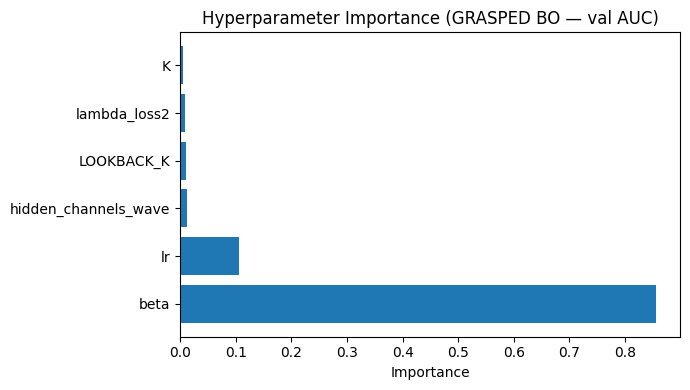


Best params saved to outputs/bo_best_params.pkl


In [23]:
import matplotlib.pyplot as plt

print('=== Best Trial ===')
best = study.best_trial
print(f'  Trial number : {best.number}')
print(f'  Best mean AUC: {best.value:.4f}')
print('  Params:')
for k, v in best.params.items():
    print(f'    {k}: {v}')

rows = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        row = {'trial': t.number, 'mean_auc': round(t.value, 5)}
        row.update(t.params)
        rows.append(row)

df_trials = pd.DataFrame(rows).sort_values('mean_auc', ascending=False).reset_index(drop=True)
print('\n=== All Completed Trials (sorted by mean val AUC) ===')
print(df_trials.to_string(index=False))

if len(df_trials) >= 5:
    importances = optuna.importance.get_param_importances(study)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(list(importances.keys()), list(importances.values()))
    ax.set_xlabel('Importance')
    ax.set_title('Hyperparameter Importance (GRASPED BO — val AUC)')
    plt.tight_layout()
    plt.savefig('outputs/bo_param_importance.png', dpi=150)
    plt.show()

with open('outputs/bo_best_params.pkl', 'wb') as f:
    pickle.dump(best.params, f)
print('\nBest params saved to outputs/bo_best_params.pkl')
